In [26]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.robust.norms as norms
from sklearn.linear_model import HuberRegressor, RANSACRegressor, TheilSenRegressor, LinearRegression
import os
import pandas as pd

Чтение данных

In [27]:
# Путь к директории с CSV-файлами
DATA_DIR = r"C:\proga\ippi\generators\lin\data_outliers"

def parse_filename(filename):
    """
    Извлекает метаинформацию из имени файла.
    
    Структура имени:
      <signal_type>_<params>_<error_category>_<n1>[_<n2>_...].csv
      signal_type:
        l – линия, параметры: a, b (y = a*x + b)
        e – эллипс, параметры: cx, cy, a_axis, b_axis, theta
        p – парабола, параметры: h, k, A 
        h – гипербола, параметры: h, k, a, b
      error_category:
        l – выброс в форме линии
        s – статические выбросы
        r – случайное распределение помех
      После error_category идут от 1 до 5 чисел, каждое задаёт количество точек выброса для группы.
    """

    # Убираем расширение .csv
    name = filename.replace(".csv", "")
    parts = name.split("_")
    
    if not parts:
        raise ValueError("Неверное имя файла: пустая строка.")
    
    # Первый символ — тип сигнала
    signal_type = parts[0]
    meta = {"signal_type": signal_type}
    idx = 1
    
    if signal_type == "l":
        # Ожидается два параметра: a и b
        if len(parts) < idx + 2 + 1:
            raise ValueError(f"Неверное имя файла {filename}: недостаточно параметров для линии.")
        try:
            a = float(parts[idx])
            b = float(parts[idx + 1])
        except ValueError:
            raise ValueError(f"Неверный формат параметров для линии в {filename}.")
        meta["params"] = {"a": a, "b": b}
        idx += 2
    elif signal_type == "e":
        # Эллипс: 5 параметров: cx, cy, a_axis, b_axis, theta
        if len(parts) < idx + 5 + 1:
            raise ValueError(f"Неверное имя файла {filename}: недостаточно параметров для эллипса.")
        try:
            cx, cy, a_axis, b_axis, theta = map(float, parts[idx:idx+5])
        except ValueError:
            raise ValueError(f"Неверный формат параметров для эллипса в {filename}.")
        meta["params"] = {"cx": cx, "cy": cy, "a_axis": a_axis, "b_axis": b_axis, "theta": theta}
        idx += 5
    elif signal_type == "p":
        # Парабола: 3 параметра: h, k, A
        if len(parts) < idx + 3 + 1:
            raise ValueError(f"Неверное имя файла {filename}: недостаточно параметров для параболы.")
        try:
            h, k, A = map(float, parts[idx:idx+3])
        except ValueError:
            raise ValueError(f"Неверный формат параметров для параболы в {filename}.")
        meta["params"] = {"h": h, "k": k, "A": A}
        idx += 3
    elif signal_type == "h":
        # Гипербола: 4 параметра: h, k, a, b
        if len(parts) < idx + 4 + 1:
            raise ValueError(f"Неверное имя файла {filename}: недостаточно параметров для гиперболы.")
        try:
            h_val, k_val, a_val, b_val = map(float, parts[idx:idx+4])
        except ValueError:
            raise ValueError(f"Неверный формат параметров для гиперболы в {filename}.")
        meta["params"] = {"h": h_val, "k": k_val, "a": a_val, "b": b_val}
        idx += 4
    else:
        raise ValueError(f"Неверный тип сигнала в {filename}: {signal_type}")
    
    # Следующий элемент — категория ошибки
    if idx >= len(parts):
        raise ValueError(f"В имени файла {filename} отсутствует категория ошибки.")
    error_category = parts[idx]
    if error_category not in {"l", "s", "r"}:
        raise ValueError(f"Неверная категория ошибки в {filename}: {error_category}")
    meta["error_category"] = error_category
    idx += 1
    
    # Остальные элементы (если есть) — числа, задающие количество точек выбросов для каждой группы
    outlier_counts = []
    while idx < len(parts):
        part = parts[idx].replace(".csv", "")
        try:
            count = int(part)
            outlier_counts.append(count)
        except ValueError:
            raise ValueError(f"Неверное значение количества выбросов в {filename}: {part}")
        idx += 1
    meta["outlier_counts"] = outlier_counts
    
    return meta

def read_data(filepath):
    try:
        data = pd.read_csv(filepath)
        # Если названия колонок не содержат x и y, назначим их
        if not {'x', 'y'}.issubset(data.columns):
            data.columns = ['x', 'y']
        return data['x'].values, data['y'].values
    except Exception as e:
        print(f"Ошибка при чтении файла {filepath}: {e}")
        return None, None

def process_file(filepath, plot = False):
    filename = os.path.basename(filepath)
    try:
        meta = parse_filename(filename)
    except ValueError as e:
        print(e)
        return
    
    x, y = read_data(filepath)
    if x is None or y is None:
        return
    
    if plot:
      print(f"\nОбработка файла: {filename}")
      print("Метаинформация:")
      print(f"  Тип сигнала: {meta['signal_type']}")
      print(f"  Параметры сигнала: {meta['params']}")
      print(f"  Категория ошибки: {meta['error_category']}")
      print(f"  Количество точек выбросов: {meta['outlier_counts']}")
      
      
      
      print(f"Считано точек: {len(x)}")
      # Здесь можно добавить дальнейшую обработку, например, визуализацию или распознавание сигнала.
      plt.figure(figsize=(8, 5))
      plt.scatter(x, y,  color='gray', alpha=0.7, label='Данные с выбросами')
      plt.title(f"Данные: {filename[:-4]}")
      plt.xlabel("x")
      plt.ylabel("y")
      plt.grid(True)
      plt.show()

    return x,y, meta


# process_file("C:\proga\ippi\generators\lin\data_outliers\l_0.57_0.35_s_409_409.csv", True)

Робастные эстиматоры

In [28]:
class RobustReg:
    def __init__(self, loss='huber', **kwargs):
        self.loss_name = loss
        self.loss_func = self._get_loss(loss, **kwargs)
        self.method_ = f"rlm_{loss.lower()}"
        self.coef_ = None
        self.intercept_ = None

    def fit(self, x, y):
        X = sm.add_constant(np.array(x).reshape(-1, 1)) 
        model = sm.RLM(y, X, M=self.loss_func)
        results = model.fit()
        self.intercept_ = results.params[0]
        self.coef_ = results.params[1]

    def _get_loss(self, name, **kwargs):
        name = name.lower()
        if name in ['rlm_huber', 'huber', 'hubert']:
            return norms.HuberT(t=kwargs.get('t', 1.345))
        elif name in ['tukey', 'tukeybiweight']:
            return norms.TukeyBiweight(c=kwargs.get('c', 4.685))
        elif name == 'hampel':
            return norms.Hampel(a=kwargs.get('a', 2), b=kwargs.get('b', 4), c=kwargs.get('c', 8))
        elif name == 'andrewwave':
            return norms.AndrewWave(a=kwargs.get('a', 1.339))
        elif name == 'trimmedmean':
            return norms.TrimmedMean(c=kwargs.get('c', 2.0))
        elif name == 'ramsaye':
            return norms.RamsayE(a=kwargs.get('a', 0.3))
        elif name in ['leastsquares', 'ols']:
            return norms.LeastSquares()
        else:
            raise ValueError(f"Неизвестная функция потерь: {name}")


def robust_regression_signal(x, y, method='huber', **kwargs):
    """
    Осуществляет робастную регрессию для оценки линейной зависимости и возвращает оценённые коэффициенты.
    
    Параметры:
      x, y       : входные данные (массивы)
      method     : строка, определяющая используемый метод.
                   Возможные значения:
                     -   'ransac'   – RANSACRegressor,
                     -   'theilsen' – TheilSenRegressor.
                     - Для реализации на базе statsmodels.RLM:
                         'huber', 'tukey', 'hampel', 'andrewwave',
                         'trimmedmean', 'ramsaye', 'leastsquares'
                     -   'meds' - метод наименьших медиан квадратов
    
    Возвращает:
      a_pred, b_pred – оценённые коэффициенты (наклон и свободный член).
    """
    new_methods = ['huber', 'tukey', 'hampel', 'andrewwave',
                   'trimmedmean', 'ramsaye', 'leastsquares']
    if method.lower() in new_methods:
        loss = method.lower()
        rlm_model = RobustReg(loss=loss, **kwargs)
        rlm_model.fit(x, y)
        a_pred = rlm_model.coef_
        b_pred = rlm_model.intercept_
        return a_pred, b_pred


    X = np.array(x).reshape(-1, 1)
    if method == 'meds':
        max_trials = kwargs.get('max_trials', 1000)
        best_median = np.inf
        a_best = None
        b_best = None
        X_arr = np.array(x).flatten()
        y_arr = np.array(y)
        n_samples = len(X_arr)
        for _ in range(max_trials):
            idx = np.random.choice(n_samples, 2, replace=False)
            # Если разница между выбранными x слишком мала, пропускаем итерацию.
            if np.abs(X_arr[idx[1]] - X_arr[idx[0]]) < 1e-8:
                continue
            a_temp = (y_arr[idx[1]] - y_arr[idx[0]]) / (X_arr[idx[1]] - X_arr[idx[0]])
            b_temp = y_arr[idx[0]] - a_temp * X_arr[idx[0]]
            residuals = y_arr - (a_temp * X_arr + b_temp)
            median_residual = np.median(residuals**2)
            if median_residual < best_median:
                best_median = median_residual
                a_best = a_temp
                b_best = b_temp
        if a_best is None:
            raise ValueError("LMedS не сошёлся")
        return a_best, b_best
    elif method == 'ransac':
        estimator = LinearRegression()
        model = RANSACRegressor(estimator=estimator,
                                min_samples=kwargs.get('min_samples', 0.5),
                                residual_threshold=kwargs.get('residual_threshold', 10.0),
                                max_trials=kwargs.get('max_trials', 100))
    elif method == 'theilsen':
        model = TheilSenRegressor(max_iter=kwargs.get('max_iter', 100))
    else:
        raise ValueError("Unsupported method.")
    
    model.fit(X, y)
    
    if hasattr(model, 'estimator_'):
        coef = model.estimator_.coef_
        intercept = model.estimator_.intercept_
    else:
        coef = model.coef_
        intercept = model.intercept_
    
    a_pred = coef[0] if not hasattr(coef[0], "__iter__") else coef[0][0]
    b_pred = intercept[0] if hasattr(intercept, "__iter__") else intercept
    return a_pred, b_pred





Преобразование Хафа

Оцененная прямая: y = 3.15x + -21.74
Истинная прямая: y = 2.78x + -3.37


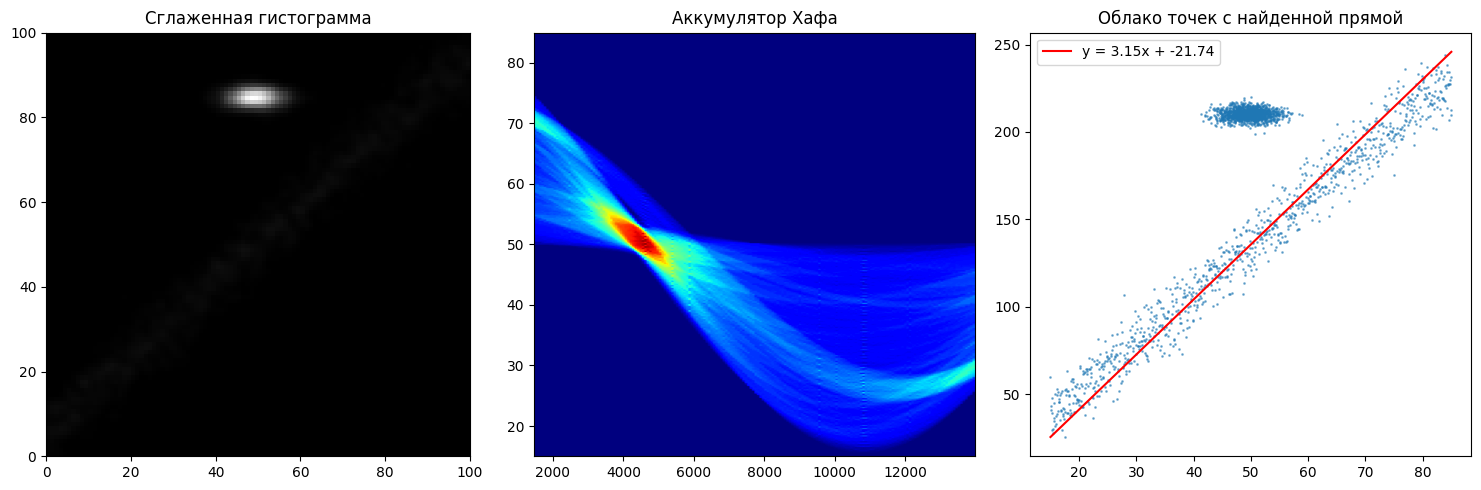

In [29]:
import cv2

from skimage.transform import hough_line, hough_line_peaks

def create_histogram(points, n=100):
    x_min, x_max = np.min(points[:, 0]), np.max(points[:, 0])
    y_min, y_max = np.min(points[:, 1]), np.max(points[:, 1])
    
    hist_2d, xedges, yedges = np.histogram2d(
        points[:, 0], points[:, 1],
        bins=n,
        range=[[x_min, x_max], [y_min, y_max]]
    )
    return hist_2d.T.astype(np.float32), (x_min, x_max, y_min, y_max)

def smooth_image(img, ksize=5, sigma=1.0):
    return cv2.GaussianBlur(img, (ksize, ksize), sigma)

def fast_hough_transform(img, theta=np.linspace(-np.pi/2, np.pi/2, 180)):
    return hough_line(img, theta=theta)

def extract_best_line(accumulator, theta, d, threshold=20):
    _, angles, dists = hough_line_peaks(accumulator, theta, d, threshold=threshold, num_peaks=1)
    return (dists[0], angles[0]) if len(angles) > 0 else None

def hough_to_line_params(rho, theta):
    """
    Преобразует параметры (ρ, θ) из хаф-пространства в модель
    row = a*col + b  (пиксельные координаты),
    где row ~ y_pix, col ~ x_pix.

    Уравнение: col*cosθ + row*sinθ = ρ.
    => row = -cosθ/sinθ * col + ρ/sinθ.
    """
    if np.isclose(np.sin(theta), 0):
        return (np.inf, rho)
    a = -np.cos(theta) / np.sin(theta)
    b = rho / np.sin(theta)
    return (a, b)

def pixel_line_to_data_line(a_pix, b_pix, x_min, x_max, y_min, y_max, n):
    """
    Преобразует пиксельную прямую row = a_pix*col + b_pix
    в координаты данных (x, y).

    row, col ∈ [0, n-1],   row=0 => y_min, row=n-1 => y_max,
                           col=0 => x_min, col=n-1 => x_max.

    =>  y = y_min + (y_max-y_min)*(row/(n-1))
        x = x_min + (x_max-x_min)*(col/(n-1))

    Подставим row = a_pix*col + b_pix:
        y = y_min + (y_max-y_min)/(n-1)*[ a_pix*col + b_pix ].
        col в реальных координатах: x = x_min + (x_max-x_min)*col/(n-1)  => col = ((x - x_min)*(n-1)) / (x_max-x_min).

    Итого получаем y как функцию x: 
    y = y_min + (y_max-y_min)/(n-1)*[ a_pix*((x - x_min)*(n-1)/(x_max-x_min)) + b_pix ].
    """
    x_range = x_max - x_min
    y_range = y_max - y_min
    scale_x = (n - 1) / x_range if x_range != 0 else 0
    scale_y = y_range / (n - 1) if n > 1 else 0
    
    def line_func(x):
        col = (x - x_min) * scale_x
        row = a_pix * col + b_pix
        return y_min + row * scale_y
    
    return line_func

def fht_line_extraction(points, n=100, ksize=5, sigma=1.0, threshold=20):
    """
    Полный пайплайн БПХ.
      1) Гистограмма + транспонирование => hist[row, col],
      2) Сглаживание,
      3) Хафа => (acc, θ, ρ),
      4) extract_best_line => (ρ, θ),
      5) из (ρ, θ) получаем (a_pix, b_pix) => row=a_pix*col+b_pix,
      6) строим функцию line_data_coords(x).
    Возвращает:
      line_data_func(x)   : функция, дающая y
      a_pix, b_pix        : наклон/сдвиг в пиксельных координатах,
      accumulator,
      ranges = (x_min, x_max, y_min, y_max).
    """
    hist, ranges = create_histogram(points, n)
    img_smoothed = smooth_image(hist, ksize, sigma)
    accumulator, thetas, ds = fast_hough_transform(img_smoothed)
    
    if (best_line := extract_best_line(accumulator, thetas, ds, threshold)) is None:
        return None
    
    rho, theta = best_line
    a_pix, b_pix = hough_to_line_params(rho, theta)
    line_func = pixel_line_to_data_line(a_pix, b_pix, *ranges, n)
    
    # Вычисляем параметры прямой в реальных координатах
    x_min, x_max = ranges[0], ranges[1]
    x1, x2 = x_min, x_max
    y1, y2 = line_func(x1), line_func(x2)
    
    if x2 != x1:
        a_real = (y2 - y1) / (x2 - x1)
        b_real = y1 - a_real * x1
    else:
        a_real = np.inf
        b_real = x1
    
    return (line_func, a_real, b_real, a_pix, b_pix, accumulator, ranges)

def plot_fht_results(points, hist, line_func, a_real, b_real, accumulator, ranges):
    x_min, x_max, y_min, y_max = ranges
    plt.figure(figsize=(15, 5))
    
    # Гистограмма
    plt.subplot(131)
    plt.imshow(hist, extent=[0, hist.shape[1], 0, hist.shape[0]], 
               cmap='gray', origin='lower')
    plt.title('Сглаженная гистограмма')
    
    # Пространство Хафа
    plt.subplot(132)
    plt.imshow(accumulator, cmap='jet', aspect='auto',
               extent=[np.rad2deg(ranges[2]), np.rad2deg(ranges[3]), 
                       ranges[0], ranges[1]])
    plt.title('Аккумулятор Хафа')
    
    # Результат
    plt.subplot(133)
    plt.scatter(points[:,0], points[:,1], s=1, alpha=0.5)
    x_vals = np.linspace(x_min, x_max, 100)
    plt.plot(x_vals, line_func(x_vals), 'r-', 
             label=f'y = {a_real:.2f}x + {b_real:.2f}')
    plt.title('Облако точек с найденной прямой')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Пример использования
# filepath = r"C:\proga\ippi\generators\lin\data_outliers\l_2.99_3.14_s_269_269.csv"
filepath = r"C:\proga\ippi\generators\lin\data_outliers\l_2.78_-3.37_s_1222.csv"
x, y, meta = process_file(filepath)  # Ваша функция загрузки данных

result = fht_line_extraction(np.column_stack((x, y)))
if result:
    line_func, a_real, b_real, a_pix, b_pix, accumulator, ranges = result
    print(f"Оцененная прямая: y = {a_real:.2f}x + {b_real:.2f}")
    
    if 'params' in meta:
        print(f"Истинная прямая: y = {meta['params']['a']:.2f}x + {meta['params']['b']:.2f}")
    
    plot_fht_results(np.column_stack((x, y)), 
                    smooth_image(create_histogram(np.column_stack((x, y)))[0]), 
                    line_func, a_real, b_real, accumulator, ranges)

Метрика

In [30]:
def compute_center_r(x, y):
    x_min, x_max = np.min(x), np.max(x)
    y_min, y_max = np.min(y), np.max(y)
    center = ((x_min + x_max) / 2, (y_min + y_max) / 2)
    R = np.sqrt((x_max - x_min)**2 + (y_max - y_min)**2) / 2
    return center, R

def line_circle_intersections(m, c, center, R):
    """
    Находит точки пересечения прямой y = m*x + c с окружностью с центром center и радиусом R.
    Возвращает массив из двух точек в виде [(x1, y1), (x2, y2)].
    Решается квадратное уравнение (x - cx)^2 + (m*x + c - cy)^2 = R^2.
    """

    cx, cy = center
    A = 1 + m**2
    B = -2 * cx + 2 * m * (c - cy)
    C = cx**2 + (c - cy)**2 - R**2
    
    disc = B**2 - 4*A*C
    sqrt_disc = np.sqrt(disc)

    x1 = (-B + sqrt_disc) / (2*A)
    x2 = (-B - sqrt_disc) / (2*A)
    y1 = m*x1 + c
    y2 = m*x2 + c

    return [(x1, y1), (x2, y2)]

def point_to_angle(pt, center):
    dx = pt[0] - center[0]
    dy = pt[1] - center[1]
    angle = np.arctan2(dy, dx)
    if angle < 0:
        angle += 2 * np.pi
    return angle

def compute_line_angles(m, c, center, R):
    points = line_circle_intersections(m, c, center, R)

    angles = [point_to_angle(pt, center) for pt in points]
    angles.sort()
    return angles

def compute_metric(x, y, meta, a_pred, b_pred):
    """
    Вычисляет метрику качества предсказания.
      1. Вычисляем описанную окружность вокруг данных.
      2. Для истинной прямой (y = meta['params']['a']*x + meta['params']['b']) и
         оценённой прямой (y = a_pred*x + b_pred) находим точки пересечения с окружностью.
      3. Преобразуем полученные точки в полярные углы.
      4. Вычисляем разность углов и берём максимальное значение.
      5. Результат нормируется в процентах (от 2π).
    """
    center, R = compute_center_r(x, y)
    true_a = meta['params']['a']
    true_b = meta['params']['b']
    
    true_angles = compute_line_angles(true_a, true_b, center, R)
    pred_angles = compute_line_angles(a_pred, b_pred, center, R)
    
    diff1 = min(abs(true_angles[0] - pred_angles[0]), 2*np.pi - abs(true_angles[0] - pred_angles[0]))
    diff2 = min(abs(true_angles[1] - pred_angles[1]), 2*np.pi - abs(true_angles[1] - pred_angles[1]))
    
    metric = max(diff1, diff2)
    return (100 * metric / (2*np.pi))



In [31]:
def plot_regression(x, y, a_pred, b_pred, meta, title="Робастная оценка сигнала"):
    """
    Строит график исходных данных, оценённой линии (красная) и истинной линии (фиолетовая),
    выводя уравнения прямых в легенде.
    """
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color='gray', alpha=0.7, label="Данные с выбросами")
    
    x_line = np.linspace(np.min(x), np.max(x), 200)
    y_line = a_pred * x_line + b_pred
    plt.plot(x_line, y_line, color='red', linewidth=2,
             label=f"Оценённая: y = {a_pred:.2f}x + {b_pred:.2f}")
    
    y_true = meta['params']['a'] * x_line + meta['params']['b']
    plt.plot(x_line, y_true, color='purple', linestyle="--", linewidth=2,
             label=f"Истинная: y = {meta['params']['a']:.2f}x + {meta['params']['b']:.2f}")
    
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def solve(filepath, plot_reg=False):
    """
    Обрабатывает один файл и возвращает DataFrame со следующими данными:
      - type           : тип сигнала,
      - noise          : процент зашумлённости,
      - type_model     : использованный метод робастной регрессии,
      - metric         : метрика качества,
      - a_true, b_true : истинные коэффициенты,
      - a_pred, b_pred : оценённые коэффициенты.
    """
    x, y, meta = process_file(filepath)
    
    # Процент зашумлённости = (сумма outlier_counts / общее число точек) * 100
    total_points = len(x)
    noise_percentage = (sum(meta.get("outlier_counts", [])) / total_points) * 100
    
    methods = ['huber', 'tukey', 'hampel', 'andrewwave','trimmedmean', 'ramsaye', 'leastsquares', 'ransac', 'theilsen','meds', 'hough']
    results = []
    
    for method in methods:
        if method == 'hough':
            try:
                hough_result = fht_line_extraction(np.column_stack((x, y)))
                if hough_result is None:
                    raise ValueError("Hough transform failed")
                    
                line_func, a_real, b_real, *_ = hough_result
                a_pred, b_pred = a_real, b_real
                
            except Exception as e:
                print(f"Ошибка в методе Хафа: {str(e)}")
                a_pred, b_pred = np.nan, np.nan
                
            metric_val = compute_metric(x, y, meta, a_pred, b_pred) if not np.isnan(a_pred) else np.nan
        else:
            a_pred, b_pred = robust_regression_signal(x, y, method=method, epsilon=1.35)
            metric_val = compute_metric(x, y, meta, a_pred, b_pred)
        
        results.append({
            "type": meta["signal_type"],
            "noise": round(noise_percentage),
            "type_model": method,
            "metric": round(metric_val, 1),
            "a_true": round(meta["params"].get("a", np.nan), 2),
            "b_true": round(meta["params"].get("b", np.nan), 2),
            "a_pred": round(a_pred, 2),
            "b_pred": round(b_pred, 2)
        })
        
        if plot_reg:
            plot_regression(x, y, a_pred, b_pred, meta, title=f"Метод: {method}")
    

    df_results = pd.DataFrame(results)
    df_results.index.name = "index"
    return df_results

def process_all_files(data_dir):
    df = pd.DataFrame()
    for file in os.listdir(data_dir):
        if file.lower().endswith(".csv"):
            filepath = os.path.join(data_dir, file)
            df_new = solve(filepath)
            df = pd.concat([df, df_new])
    return df

df = process_all_files(DATA_DIR)
df


,type,noise,type_model,metric,a_true,b_true,a_pred,b_pred
index,,,,,,,,
0,l,15,huber,6.5,0.50,0.60,0.98,-28.26
1,l,15,tukey,6.6,0.50,0.60,0.98,-28.67
2,l,15,hampel,7.0,0.50,0.60,1.02,-31.26
3,l,15,andrewwave,6.6,0.50,0.60,0.98,-28.66
4,l,15,trimmedmean,6.2,0.50,0.60,0.95,-26.25
...,...,...,...,...,...,...,...,...
6,l,35,leastsquares,1.0,2.99,3.14,2.93,-19.02
7,l,35,ransac,1.3,2.99,3.14,2.69,-0.86
8,l,35,theilsen,0.7,2.99,3.14,2.72,9.29


In [32]:
df.to_csv("results.csv")

График зависимости метрики от сетепени зашумленности данных

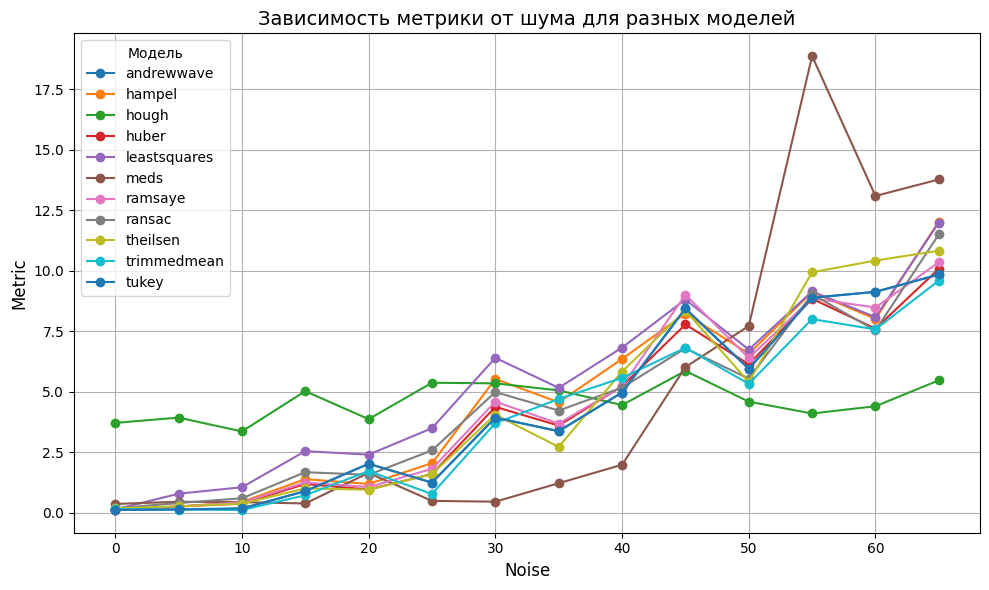

In [33]:
df = pd.read_csv('results.csv')

# Группировка по модели и шуму, расчёт средней метрики и стандартного отклонения
grouped_df = (
    df
    .groupby(['type_model', 'noise'], as_index=False)
    .agg({'metric': ['mean']})
)

# Переименование столбцов после группировки
grouped_df.columns = ['type_model', 'noise', 'metric_mean']

# Построение графика
plt.figure(figsize=(10, 6))

for model_name in grouped_df['type_model'].unique():
    subset = grouped_df[grouped_df['type_model'] == model_name]
    plt.errorbar(
        x=subset['noise'],
        y=subset['metric_mean'],
        label=model_name,
        marker='o',
        capsize=3
    )

plt.xlabel('Noise', fontsize=12)
plt.ylabel('Metric', fontsize=12)
plt.title('Зависимость метрики от шума для разных моделей', fontsize=14)
plt.legend(title='Модель')
plt.grid(True)
plt.tight_layout()
plt.show()

График зависимости абсолютной разницы наклонов прямой от степени зашумленности

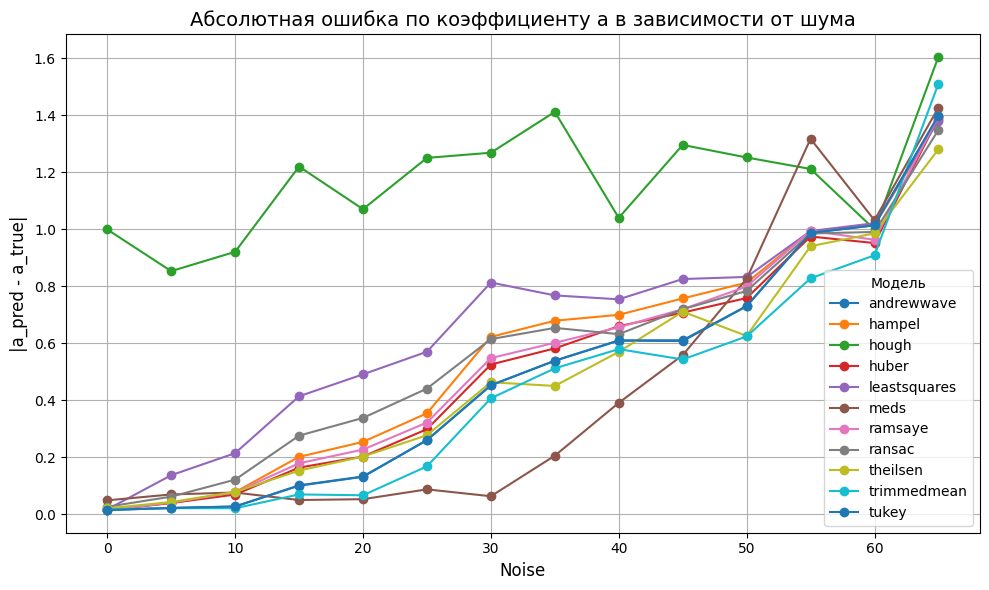

In [34]:
df = pd.read_csv('results.csv')
# Вычисляем абсолютную разницу |a_pred - a_true|
df['a_error'] = (df['a_pred'] - df['a_true']).abs()

# Группировка по модели и шуму
grouped_a_error = (
    df
    .groupby(['type_model', 'noise'], as_index=False)
    .agg({'a_error': ['mean']})
)

# Переименование колонок
grouped_a_error.columns = ['type_model', 'noise', 'a_error_mean']

# Построение графика
plt.figure(figsize=(10, 6))

for model_name in grouped_a_error['type_model'].unique():
    subset = grouped_a_error[grouped_a_error['type_model'] == model_name]
    plt.errorbar(
        x=subset['noise'],
        y=subset['a_error_mean'],
        label=model_name,
        marker='o',
        capsize=3
    )

plt.xlabel('Noise', fontsize=12)
plt.ylabel('|a_pred - a_true|', fontsize=12)
plt.title('Абсолютная ошибка по коэффициенту a в зависимости от шума', fontsize=14)
plt.legend(title='Модель')
plt.grid(True)
plt.tight_layout()
plt.show()

График зависмости абсолютного отклонения коэффициента b от степени зашумленности данных

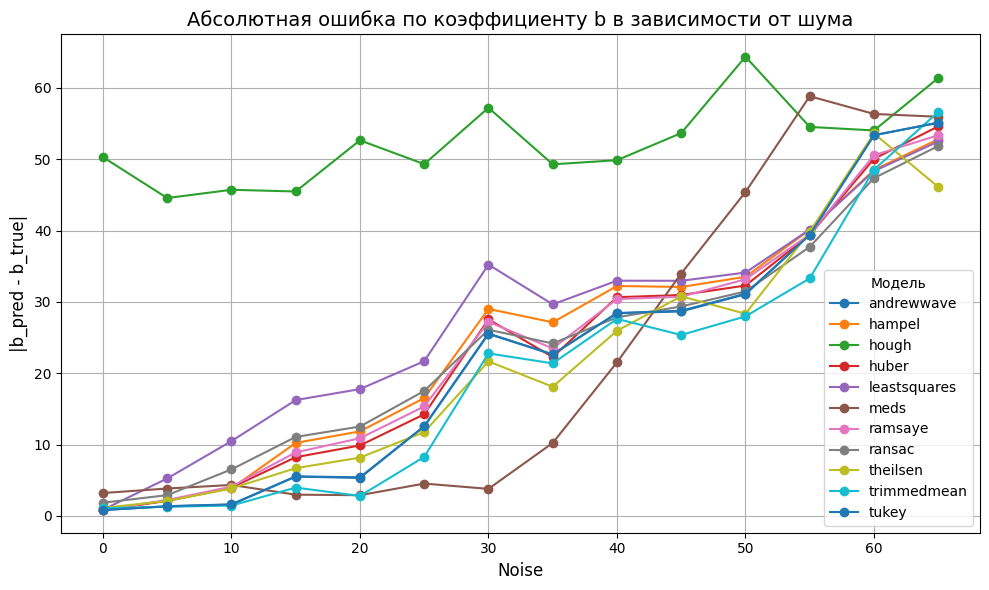

In [35]:
df = pd.read_csv('results.csv')
# Вычисляем абсолютную разницу |b_pred - b_true|
df['b_error'] = (df['b_pred'] - df['b_true']).abs()

# Группировка по модели и шуму
grouped_b_error = (
    df
    .groupby(['type_model', 'noise'], as_index=False)
    .agg({'b_error': ['mean']})
)

# Переименование колонок
grouped_b_error.columns = ['type_model', 'noise', 'b_error_mean']

# Построение графика
plt.figure(figsize=(10, 6))

for model_name in grouped_b_error['type_model'].unique():
    subset = grouped_b_error[grouped_b_error['type_model'] == model_name]
    plt.errorbar(
        x=subset['noise'],
        y=subset['b_error_mean'],
        label=model_name,
        marker='o',
        capsize=3
    )

plt.xlabel('Noise', fontsize=12)
plt.ylabel('|b_pred - b_true|', fontsize=12)
plt.title('Абсолютная ошибка по коэффициенту b в зависимости от шума', fontsize=14)
plt.legend(title='Модель')
plt.grid(True)
plt.tight_layout()
plt.show()